<a href="https://colab.research.google.com/github/Luisk026/Clase-7/blob/main/S19_Analisis_Exploratorio_Portafolios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [22]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
ticker = ["PFE"]

datos = yf.download(
    ticker,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=False
)

datos.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,PFE,PFE,PFE,PFE,PFE,PFE
Date,,,,,,
2024-01-02,24.844589,29.730000,30.280001,28.830000,28.879999,57948700
2024-01-03,24.844589,29.730000,30.040001,29.410000,30.000000,43426500
2024-01-04,24.309757,29.090000,29.950001,29.030001,29.790001,45558200
2024-01-05,24.627314,29.469999,29.490000,28.750000,29.020000,33612800
2024-01-08,24.719242,29.580000,29.680000,29.170000,29.360001,32972100


In [32]:
ticker = ["CAT"]

datos = yf.download(
    ticker,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,CAT,CAT,CAT,CAT,CAT,CAT
Date,,,,,,
2024-01-02,282.079895,292.709991,296.640015,291.350006,293.429993,2433100
2024-01-03,273.975250,284.299988,288.929993,283.320007,288.390015,3043400
2024-01-04,275.709930,286.100006,288.220001,283.790009,284.410004,2995400
2024-01-05,278.437134,288.929993,291.000000,285.470001,286.250000,2684800
2024-01-08,281.636597,292.250000,292.679993,285.239990,287.559998,2369100


In [33]:
ticker = ["INTC"]

datos = yf.download(
    ticker,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,INTC,INTC,INTC,INTC,INTC,INTC
Date,,,,,,
2024-01-02,47.168282,47.799999,49.380001,47.450001,49.200001,45905700
2024-01-03,46.428192,47.049999,47.810001,46.799999,47.099998,35858400
2024-01-04,46.250572,46.869999,47.160000,45.240002,45.720001,47797800
2024-01-05,46.270306,46.889999,47.830002,46.639999,47.029999,34344000
2024-01-08,47.809692,48.450001,48.759998,46.970001,47.070000,42135100


## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

In [40]:
# Definimos los 3 activos elegidos
tickers = ["PFE", "CAT", "INTC"]

# Descargamos los datos para los 3 activos a la vez
datos_portafolio = yf.download(
    tickers,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=False
)

# 1. Filtramos y extraemos únicamente los precios de cierre (Close)
precios_cierre = datos_portafolio['Close']
precios_cierre.head()

[*********************100%***********************]  3 of 3 completed


Ticker,CAT,INTC,PFE
Date,,,
2024-01-02,292.709991,47.799999,29.730000
2024-01-03,284.299988,47.049999,29.730000
2024-01-04,286.100006,46.869999,29.090000
2024-01-05,288.929993,46.889999,29.469999
2024-01-08,292.250000,48.450001,29.580000


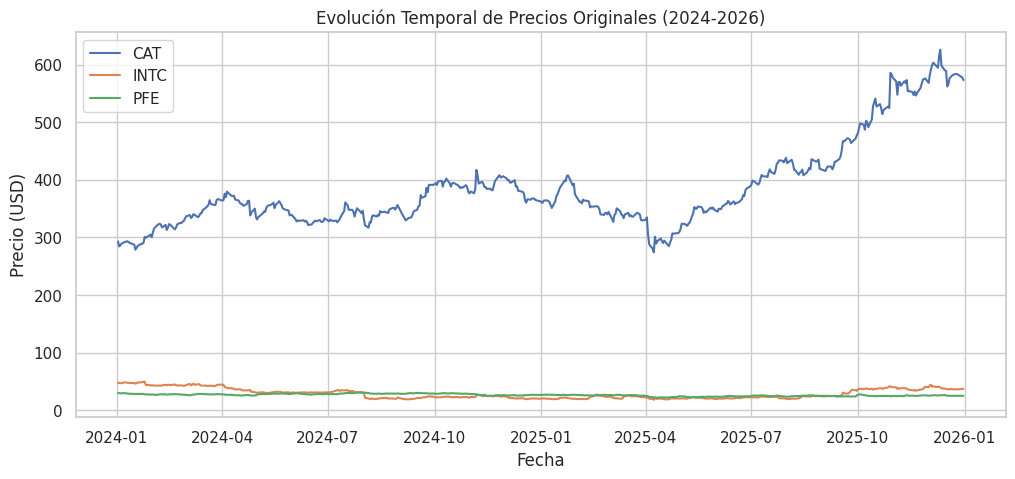

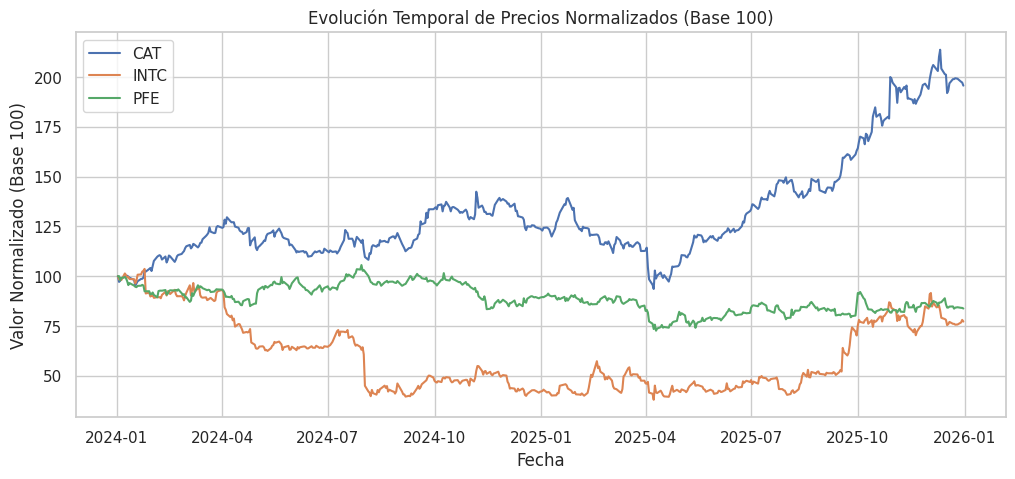

In [49]:
# 2. Graficar precios originales
plt.figure(figsize=(12, 5))
plt.plot(precios_cierre)
plt.title('Evolución Temporal de Precios Originales (2024-2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend(precios_cierre.columns)
plt.grid(True)
plt.show()

# 3. Normalizar (base 100 en el primer registro) y graficar
# Dividimos cada fila por el primer registro (fila 0) y multiplicamos por 100
precios_normalizados = (precios_cierre / precios_cierre.iloc[0]) * 100

plt.figure(figsize=(12, 5))
plt.plot(precios_normalizados)
plt.title('Evolución Temporal de Precios Normalizados (Base 100)')
plt.xlabel('Fecha')
plt.ylabel('Valor Normalizado (Base 100)')
plt.legend(precios_normalizados.columns)
plt.grid(True)
plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

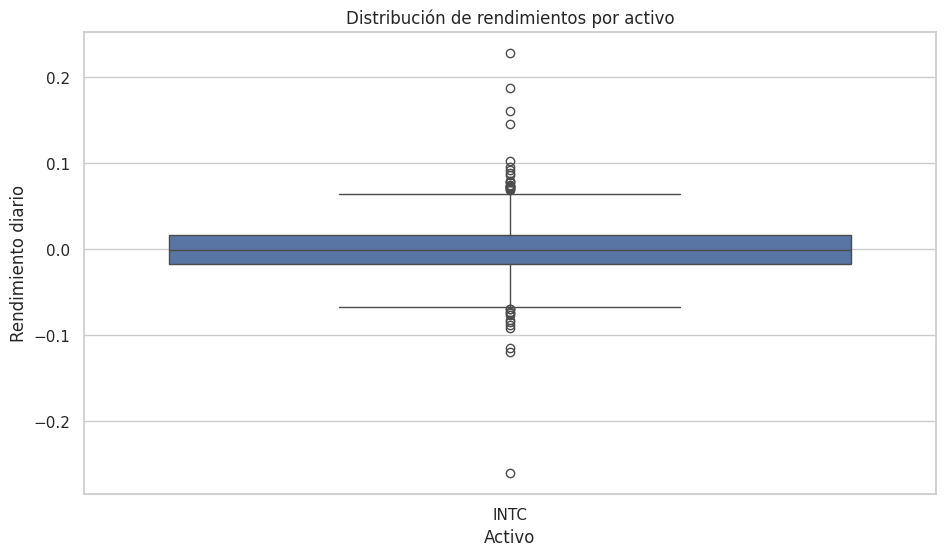

In [47]:
plt.figure(figsize=(11, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()

Primeras filas de los rendimientos diarios:
Ticker           CAT      INTC       PFE
Date                                    
2024-01-03 -0.028732 -0.015690  0.000000
2024-01-04  0.006331 -0.003826 -0.021527
2024-01-05  0.009892  0.000427  0.013063
2024-01-08  0.011491  0.033269  0.003733
2024-01-09  0.000137 -0.008256 -0.006085

El activo más volátil es: INTC (Desviación estándar: 0.0365)


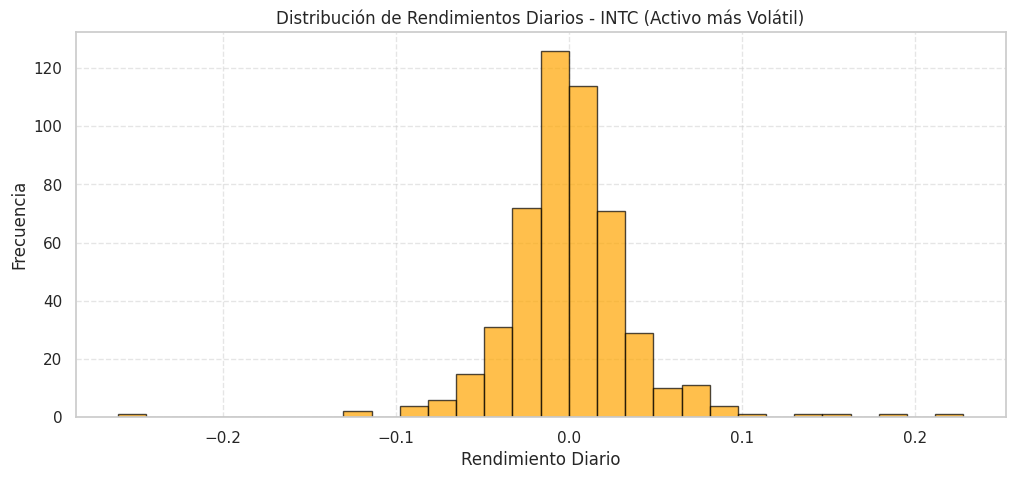

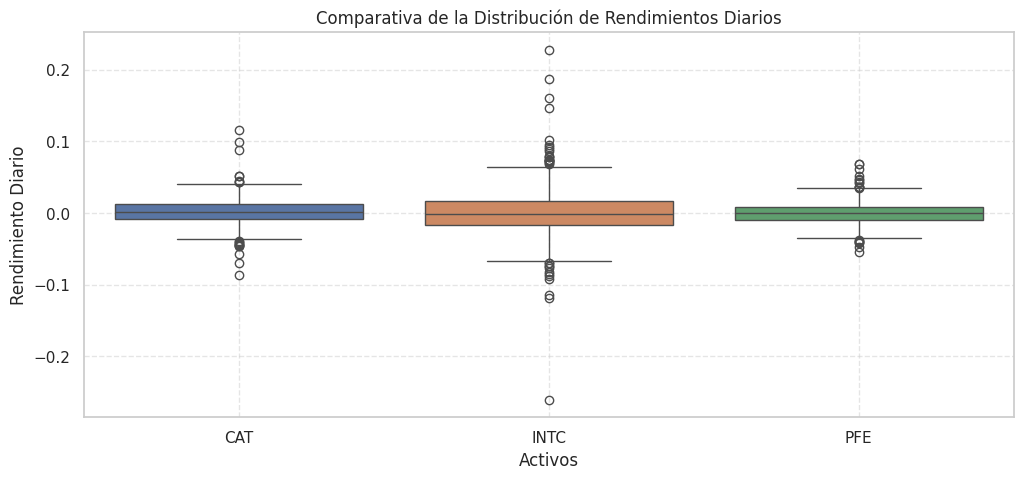

In [50]:
# 1. Calcular rendimientos de los 3 activos y eliminar nulos
rendimientos = precios_cierre.pct_change().dropna()
print("Primeras filas de los rendimientos diarios:")
print(rendimientos.head())

# Determinar el activo más volátil mediante la desviación estándar
volatilidad = rendimientos.std()
activo_mas_volatil = volatilidad.idxmax()
print(f"\nEl activo más volátil es: {activo_mas_volatil} (Desviación estándar: {volatilidad[activo_mas_volatil]:.4f})")

# 2. Histograma con el activo más volátil (Se corrige la tupla de figsize)
plt.figure(figsize=(12, 5))
plt.hist(rendimientos[activo_mas_volatil], bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.title(f'Distribución de Rendimientos Diarios - {activo_mas_volatil} (Activo más Volátil)')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Boxplot comparativo de rendimientos
import seaborn as sns
plt.figure(figsize=(12, 5))
sns.boxplot(data=rendimientos)
plt.title('Comparativa de la Distribución de Rendimientos Diarios')
plt.xlabel('Activos')
plt.ylabel('Rendimiento Diario')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

Matriz de Correlación de Pearson:
Ticker       CAT      INTC       PFE
Ticker                              
CAT     1.000000  0.335234  0.207134
INTC    0.335234  1.000000  0.183222
PFE     0.207134  0.183222  1.000000


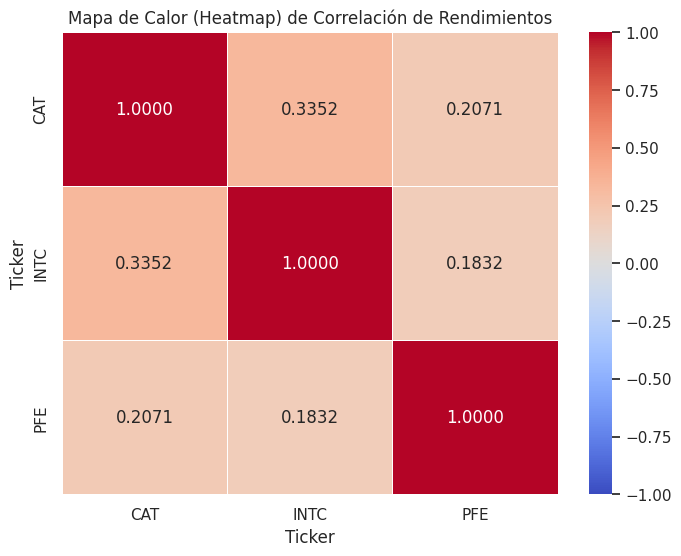

In [54]:
# 1. Calcular matriz de correlación de Pearson para los rendimientos
matriz_correlacion = rendimientos.corr(method='pearson')
print("Matriz de Correlación de Pearson:")
print(matriz_correlacion)

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion,
    annot=True,          # Muestra los valores numéricos dentro de las celdas
    cmap='coolwarm',     # Paleta de colores de frío a caliente
    vmin=-1,             # Valor mínimo de la escala de correlación
    vmax=1,              # Valor máximo de la escala de correlación
    fmt=".4f",           # Formato de cuatro decimales
    linewidths=0.5       # Línea divisoria entre celdas
)

plt.title('Mapa de Calor (Heatmap) de Correlación de Rendimientos')
plt.show()

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [56]:
# 1. Generamos el resumen estadístico con las funciones requeridas y transponemos el DataFrame
resumen_estadistico = rendimientos.agg(['mean', 'median', 'std', 'min', 'max']).T

# 2. Renombramos las columnas al español
resumen_estadistico.columns = ['Media', 'Mediana', 'Desviación Estándar', 'Mínimo', 'Máximo']

# 3. Mostramos el resultado
print(resumen_estadistico)

           Media   Mediana  Desviación Estándar    Mínimo    Máximo
Ticker                                                             
CAT     0.001509  0.001127             0.018370 -0.086356  0.116346
INTC    0.000151 -0.000826             0.036541 -0.260585  0.227711
PFE    -0.000232  0.000000             0.015652 -0.054343  0.068344


In [ ]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)